# DIEU YEN DIEP: VISUALISATION AND DOCUMENTATION

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

possible_folders = [Path.cwd(), Path.cwd() / "Data Science", Path.home() / "Desktop" / "Data Science"]
project_folder = next(
    (folder.resolve() for folder in possible_folders if (folder / "Fire2Air_model_ready_checkpoint.csv").exists()),
    None,
)
if project_folder is None:
    raise FileNotFoundError("Fire2Air_model_ready_checkpoint.csv not found. Run Thi's notebook first.")

output_root = project_folder / "outputs_prt661"
table_dir = output_root / "tables"
figure_dir = output_root / "figures"
for folder in [table_dir, figure_dir]:
    folder.mkdir(parents=True, exist_ok=True)

model_table = pd.read_csv(
    project_folder / "Fire2Air_model_ready_checkpoint.csv",
    parse_dates=["date", "target_date"],
)
daily_air = pd.read_csv(
    project_folder / "Fire2Air_ntepa_daily_checkpoint.csv",
    parse_dates=["date"],
)
fire_daily = pd.read_csv(
    project_folder / "Fire2Air_firms_daily_checkpoint.csv",
    parse_dates=["date_darwin"],
)
with open(project_folder / "Fire2Air_feature_manifest.json", "r", encoding="utf-8") as f:
    manifest = json.load(f)
model_features = manifest["features"]
PM25_THRESHOLD = float(manifest["threshold_pm25_ug_m3"])
MAX_FIRE_DISTANCE_KM = float(manifest["max_fire_distance_km"])

print("Project folder:", project_folder)
print("Model-ready rows:", len(model_table))
print("Predictors:", len(model_features))

Project folder: C:\Users\khuep\Desktop\PRT661---DATA-SCIENCE-PRACTICE---Dan5---Theme2\Source code
Model-ready rows: 7530
Predictors: 22


## A. Updated implementation architecture

This figure documents the implemented Assessment 2 flow rather than the earlier proposal-only design.

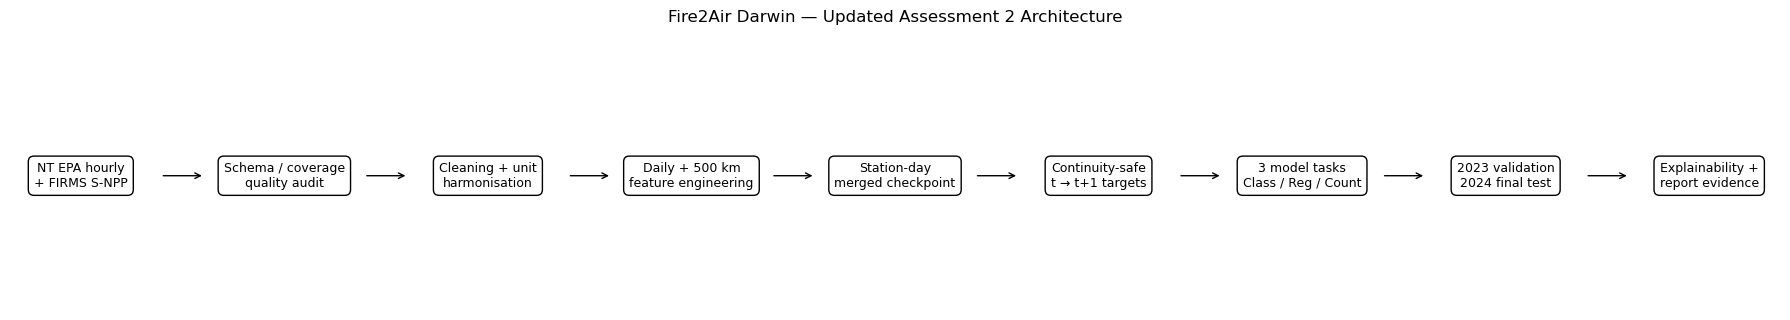

In [2]:
stages = [
    "NT EPA hourly\n+ FIRMS S-NPP",
    "Schema / coverage\nquality audit",
    "Cleaning + unit\nharmonisation",
    "Daily + 500 km\nfeature engineering",
    "Station-day\nmerged checkpoint",
    "Continuity-safe\nt → t+1 targets",
    "3 model tasks\nClass / Reg / Count",
    "2023 validation\n2024 final test",
    "Explainability +\nreport evidence",
]

fig, ax = plt.subplots(figsize=(18, 3.3))
ax.axis("off")
xs = np.linspace(0.04, 0.96, len(stages))
for i, (x, label) in enumerate(zip(xs, stages)):
    ax.text(
        x, 0.5, label, ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="black"),
        transform=ax.transAxes, fontsize=9,
    )
    if i < len(stages) - 1:
        ax.annotate(
            "", xy=(xs[i + 1] - 0.045, 0.5), xytext=(x + 0.045, 0.5),
            xycoords=ax.transAxes, textcoords=ax.transAxes,
            arrowprops=dict(arrowstyle="->"),
        )
ax.set_title("Fire2Air Darwin — Updated Assessment 2 Architecture", pad=14)
fig.tight_layout()
fig.savefig(figure_dir / "01_updated_architecture.png", dpi=180, bbox_inches="tight")
plt.show()

## B. EDA: PM₂.₅ trends, distributions, seasonality and exceedances

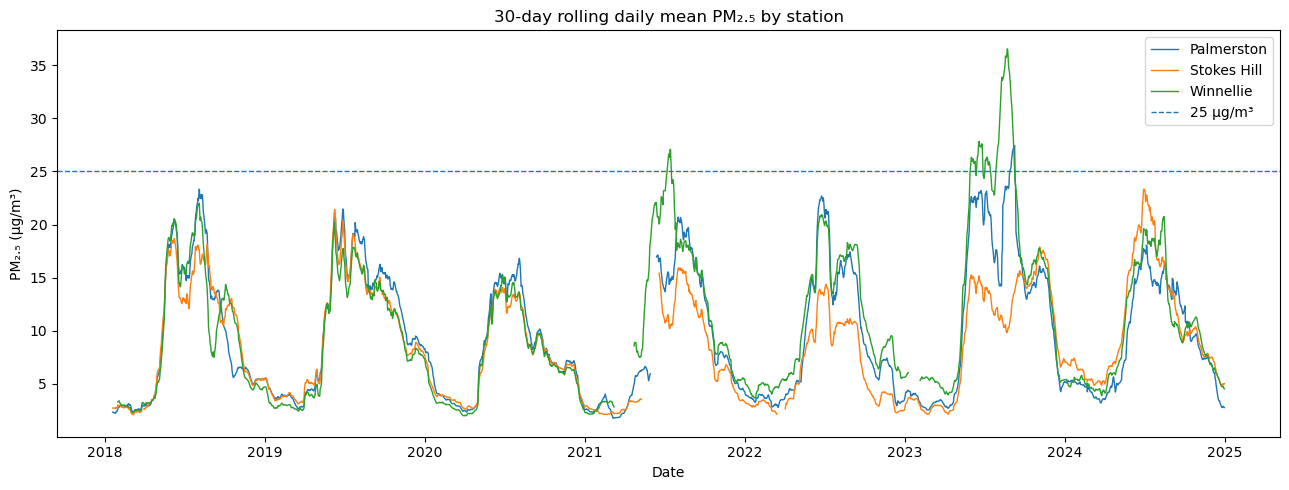

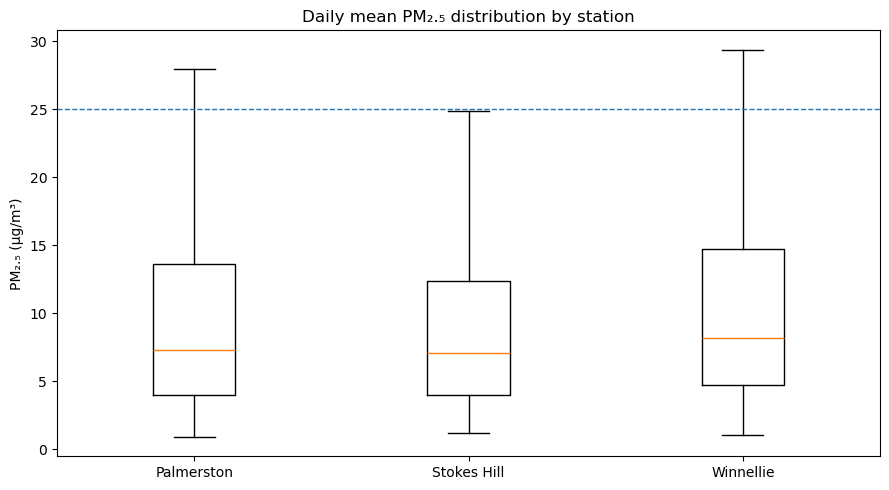

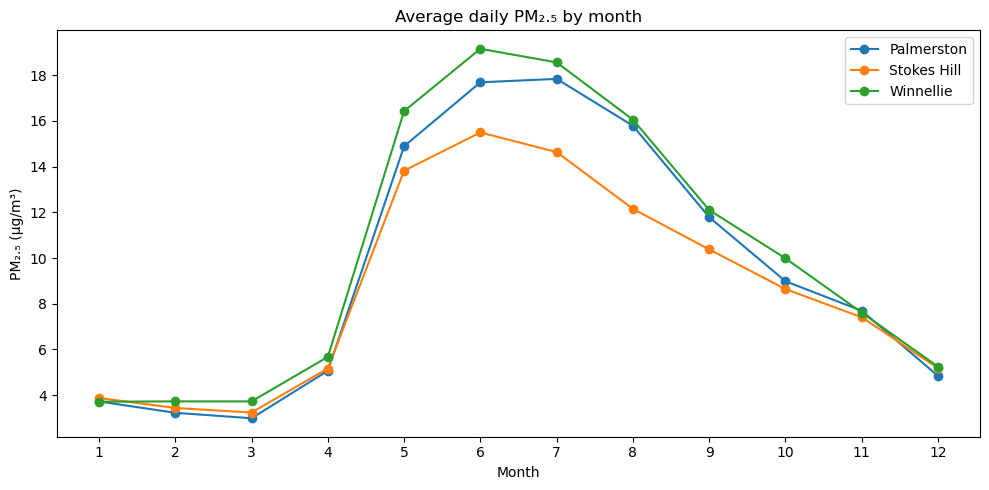

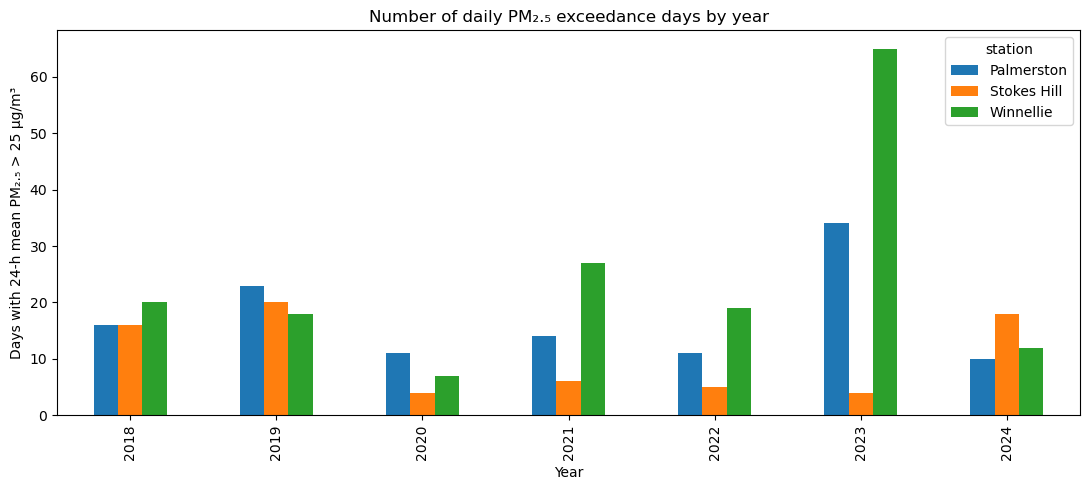

In [3]:
# 30-day rolling PM2.5 trend by station.
fig, ax = plt.subplots(figsize=(13, 5))
for station, g in daily_air.sort_values("date").groupby("station"):
    smoothed = g.set_index("date")["pm25_mean"].rolling(30, min_periods=10).mean()
    ax.plot(smoothed.index, smoothed.values, label=station, linewidth=1)
ax.axhline(PM25_THRESHOLD, linestyle="--", linewidth=1, label="25 µg/m³")
ax.set_title("30-day rolling daily mean PM₂.₅ by station")
ax.set_xlabel("Date"); ax.set_ylabel("PM₂.₅ (µg/m³)"); ax.legend()
fig.tight_layout()
fig.savefig(figure_dir / "02_pm25_trend_by_station.png", dpi=180, bbox_inches="tight")
plt.show()

# Distribution by station.
stations = sorted(daily_air["station"].dropna().unique())
data = [daily_air.loc[daily_air["station"].eq(s), "pm25_mean"].dropna() for s in stations]
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(data, tick_labels=stations, showfliers=False)
ax.axhline(PM25_THRESHOLD, linestyle="--", linewidth=1)
ax.set_title("Daily mean PM₂.₅ distribution by station")
ax.set_ylabel("PM₂.₅ (µg/m³)")
fig.tight_layout()
fig.savefig(figure_dir / "03_pm25_distribution_by_station.png", dpi=180, bbox_inches="tight")
plt.show()

# Monthly PM2.5 pattern.
monthly_pm = (
    daily_air.assign(month=daily_air["date"].dt.month)
    .groupby(["station", "month"])["pm25_mean"].mean().reset_index()
)
fig, ax = plt.subplots(figsize=(10, 5))
for station, g in monthly_pm.groupby("station"):
    ax.plot(g["month"], g["pm25_mean"], marker="o", label=station)
ax.set_xticks(range(1, 13))
ax.set_title("Average daily PM₂.₅ by month")
ax.set_xlabel("Month"); ax.set_ylabel("PM₂.₅ (µg/m³)"); ax.legend()
fig.tight_layout()
fig.savefig(figure_dir / "04_monthly_pm25_pattern.png", dpi=180, bbox_inches="tight")
plt.show()

# Exceedance days by year and station.
exceedance_counts = (
    daily_air.dropna(subset=["pm25_mean"])
    .assign(year=lambda d: d["date"].dt.year, exceedance=lambda d: (d["pm25_mean"] > PM25_THRESHOLD).astype(int))
    .groupby(["year", "station"])["exceedance"].sum()
    .unstack("station").fillna(0)
)
ax = exceedance_counts.plot(kind="bar", figsize=(11, 5))
ax.set_title("Number of daily PM₂.₅ exceedance days by year")
ax.set_xlabel("Year"); ax.set_ylabel("Days with 24-h mean PM₂.₅ > 25 µg/m³")
fig = ax.get_figure(); fig.tight_layout()
fig.savefig(figure_dir / "05_exceedance_days_by_year.png", dpi=180, bbox_inches="tight")
plt.show()